In [16]:
import os
import glob
import torch
import time
from cace.tasks import LightningTrainingTask
from deeporb.data import OrbDataset, OrbData
from deeporb.ceonet import CEONet

#Model params
CUTOFF = 7.6
LINMAX = 3
LOMAX = 2
NC = 16
LAYERS = 2
N_RBF = 16
N_RSAMPLES = 16
STACKING = True
IRREP_MIXING = False
CHARGE_EMBEDDING = False

#Data params
BATCH_SIZE = 16

print("Making dataset...")
time_start = time.perf_counter()
data = OrbData(data_path="../model_eval/as_data/aug1212_asonly.h5",batch_size=BATCH_SIZE)
data.setup()
time_stop = time.perf_counter()
print("Time elapsed:",time_stop-time_start)

representation = CEONet(NC,cutoff=CUTOFF,n_rbf=N_RBF,n_rsamples=N_RSAMPLES,stacking=STACKING,irrep_mixing=IRREP_MIXING,
                        linmax=LINMAX,lomax=LOMAX,layers=LAYERS,charge_embedding=CHARGE_EMBEDDING)

from cace.models import NeuralNetworkPotential
from deeporb.atomwise import AttentionAtomwise
import torch.nn as nn
atomwise = AttentionAtomwise(
                    output_key='pred_entropy',
                    n_hidden=[32,16],
                    attention_hidden_nc=128,
                    bias=True,
                    out_layer = nn.ReLU(),
                   )

model = NeuralNetworkPotential(
    input_modules=None,
    representation=representation,
    output_modules=[atomwise]
)
state_dict = torch.load("../model_eval/as_data/aug1212_model.pth")
model.load_state_dict(state_dict)

Making dataset...
Time elapsed: 4.490747632924467


/tmp/ipykernel_2578213/1829144695.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../model_eval/as_data/aug1212_model.pth")


<All keys matched successfully>

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 15.59it/s]


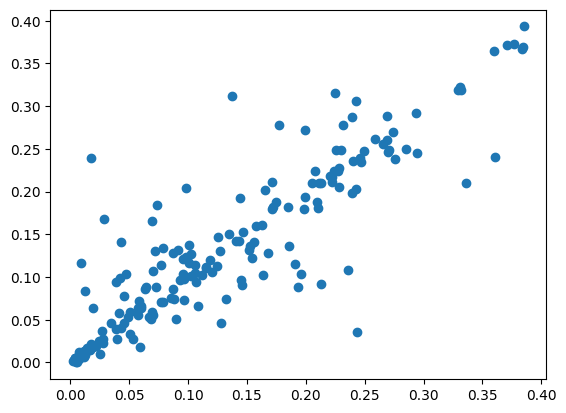

In [17]:
model.cuda()
trues = []
preds = []

import tqdm
for batch in tqdm.tqdm(data.test_dataloader()):
    batch.cuda()
    out = model.forward(batch,training=False)
    true = batch["entropy"].detach().cpu().numpy()
    pred = out["pred_entropy"].detach().cpu().numpy()
    trues.append(true)
    preds.append(pred)
    torch.cuda.empty_cache()
    # break
import numpy as np
trues = np.hstack(trues)
preds = np.hstack(preds)

import matplotlib.pyplot as plt
plt.scatter(trues,preds)

0.3852635 0.0022700934
0.3932248 0.0


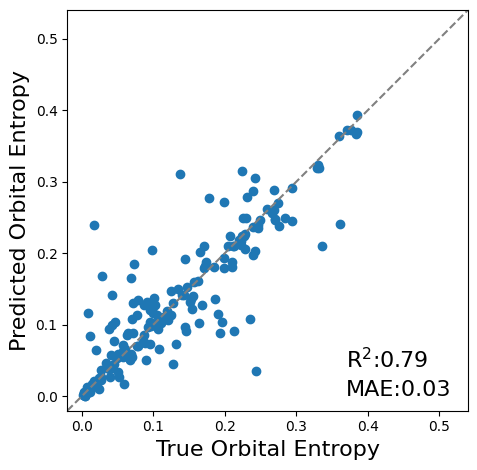

In [18]:
from dsk.pickle import load_pkl, dump_pkl

import scipy
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(trues,preds)
print(trues.max(),trues.min())
print(preds.max(),preds.min())
djvfont = {'fontname':'DejaVu Sans'}
fs = 16
tot_r2 = np.round(scipy.stats.pearsonr(trues,preds)[0]**2,2)
mae = round(np.abs(trues - preds).mean(),2)
plt.text(0.37,0.04,f"R$^2$:{tot_r2}",fontsize=fs,**djvfont)
plt.text(0.37,0,f"MAE:{mae:.2f}",fontsize=fs,**djvfont)
xmin, xmax = -0.02, 0.54
x = y = np.arange(xmin,xmax+0.03,0.01)
plt.plot(x,y,linestyle="--",color="grey")
plt.xlim(xmin,xmax)
plt.ylim(xmin,xmax)
# tcks = np.round(np.arange(xmin,xmax,1.25),2)
# plt.xticks(tcks,tcks)
# plt.yticks(tcks,tcks)
plt.gca().set_aspect('equal')
# plt.legend(loc="upper left")
plt.ylabel("Predicted Orbital Entropy",fontsize=fs,**djvfont)
plt.xlabel("True Orbital Entropy",fontsize=fs,**djvfont)
# plt.title(self.title,fontsize=fs,**djvfont)
plt.tight_layout()
plt.savefig("../figures/entropy_pred.png",dpi=500)

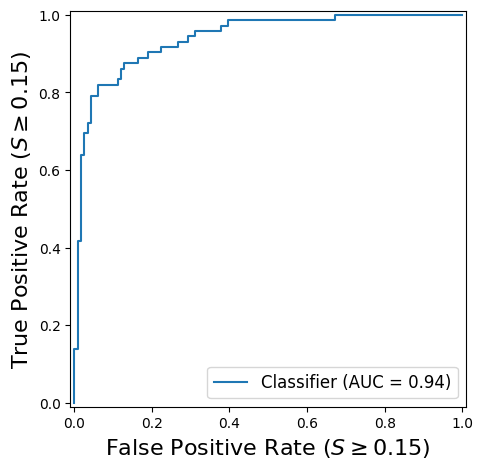

In [20]:
from sklearn.metrics import RocCurveDisplay
import torch
import seaborn as sns
obj = RocCurveDisplay
obj.from_predictions((trues > 0.15).astype(bool),preds) #Cool! :D
plt.xlabel("False Positive Rate ($S \geq 0.15$)",fontsize=fs,**djvfont)
plt.ylabel("True Positive Rate ($S \geq 0.15$)",fontsize=fs,**djvfont)
plt.legend(fontsize=12,loc="lower right")
plt.tight_layout()
plt.savefig("../figures/entropy_auc.png",dpi=500)

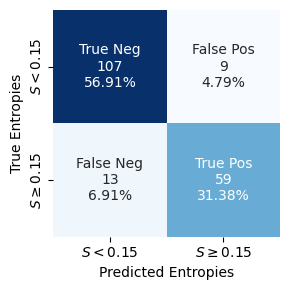

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_true = trues >= 0.15
y_pred = preds >= 0.15
cf_matrix = confusion_matrix(y_true,y_pred)
# obj = ConfusionMatrixDisplay(cm)

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in
                cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in
                     cf_matrix.flatten()/np.sum(cf_matrix)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)
import seaborn as sns
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues', ax=ax,cbar=False, 
            xticklabels=["$S < 0.15$","$S \geq 0.15$"], yticklabels=["$S < 0.15$","$S \geq 0.15$"])
plt.xlabel("Predicted Entropies")
plt.ylabel("True Entropies")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("../figures/entropy_conf_mat.png",dpi=500)